<a href="https://colab.research.google.com/github/sumanakunder/ML/blob/main/Machine_Learning_Lab_Manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Develop a program to create histograms for all numerical features and analyze
the distribution of each feature. Generate box plots for all numerical features and
identify any outliers. Use California Housing dataset


Outlier Summary using IQR Method:

MedInc: LB=-0.7063750000000004,UB=8.013024999999999,  681 outliers 
HouseAge: LB=-10.5,UB=65.5,  0 outliers 
AveRooms: LB=2.023219161170969,UB=8.469878027106942,  511 outliers 
AveBedrms: LB=0.8659085155701288,UB=1.2396965968190603,  1424 outliers 
Population: LB=-620.0,UB=3132.0,  1196 outliers 
AveOccup: LB=1.1509614824735064,UB=4.5610405893536905,  711 outliers 
Latitude: LB=28.259999999999998,UB=43.38,  0 outliers 
Longitude: LB=-127.48499999999999,UB=-112.32500000000002,  0 outliers 
MedHouseVal: LB=-0.9808749999999995,UB=4.824124999999999,  1071 outliers 


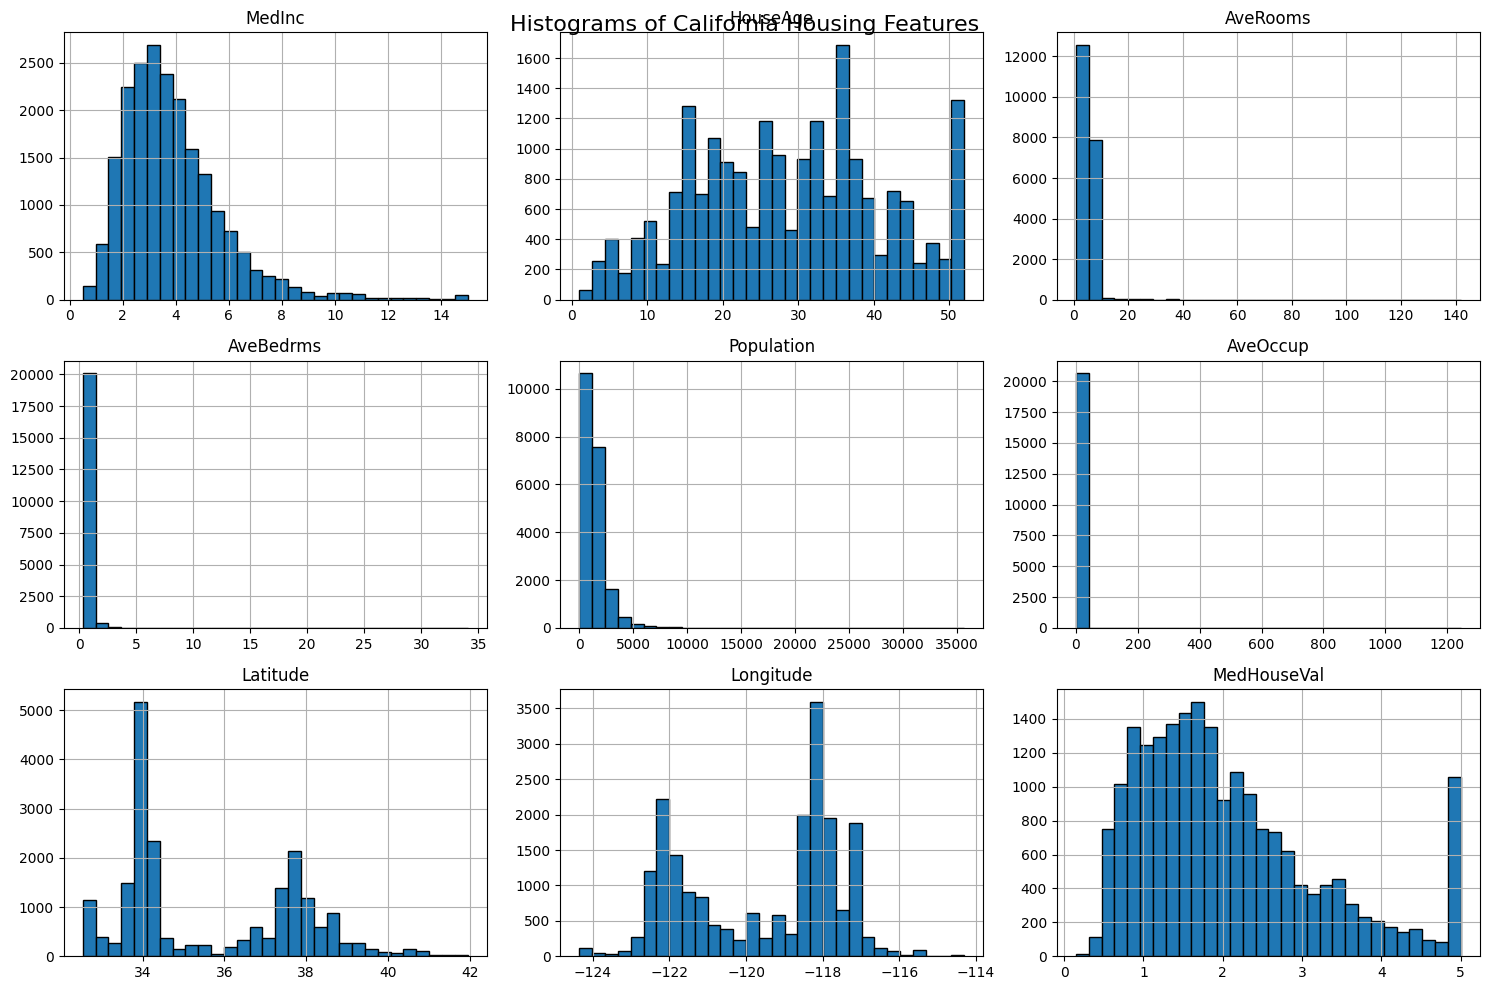

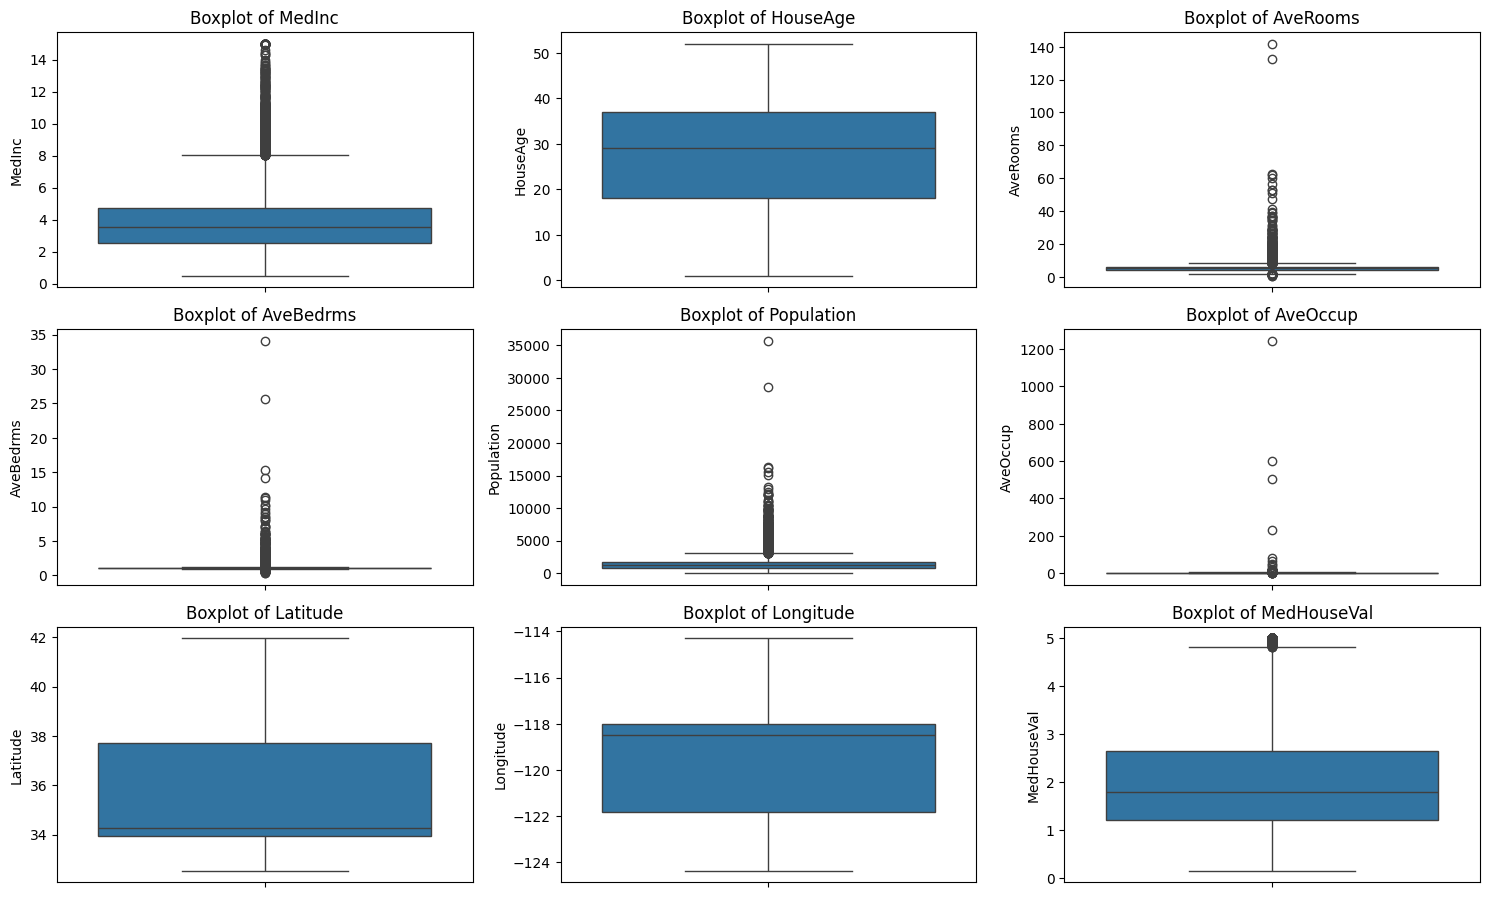

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
%matplotlib inline

# Load California Housing dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)

# Add the target (house value) to the dataframe
df['MedHouseVal'] = california.target

# ---------------------------
# Histograms for each feature
# ---------------------------
df.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout(rect=[0, 0, 1,1])
plt.suptitle("Histograms of California Housing Features", fontsize=16)  # Optional

# ----------------------------------
# Box plots to detect feature outliers
# ----------------------------------
plt.figure(figsize=(15, 12))
for i, column in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')# Optional
    plt.tight_layout() # Optional
# ----------------------------------
# Outlier detection summary (IQR method)
# ----------------------------------
print("\nOutlier Summary using IQR Method:\n")
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: LB={lower_bound},UB={upper_bound},  {len(outliers)} outliers ")

2. Develop a program to Compute the correlation matrix to understand the
relationships between pairs of features. Visualize the correlation matrix using a
heatmap to know which variables have strong positive/negative correlations.
Create a pair plot to visualize pairwise relationships between features. Use
California Housing dataset


Text(0.5, 1.02, 'Pair Plot of California Housing Features')

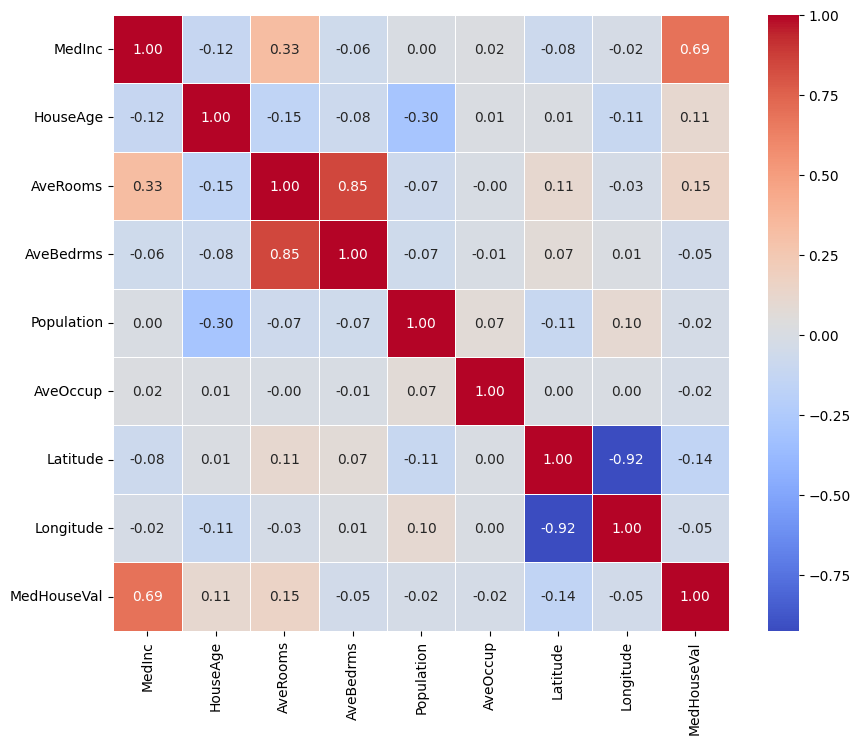

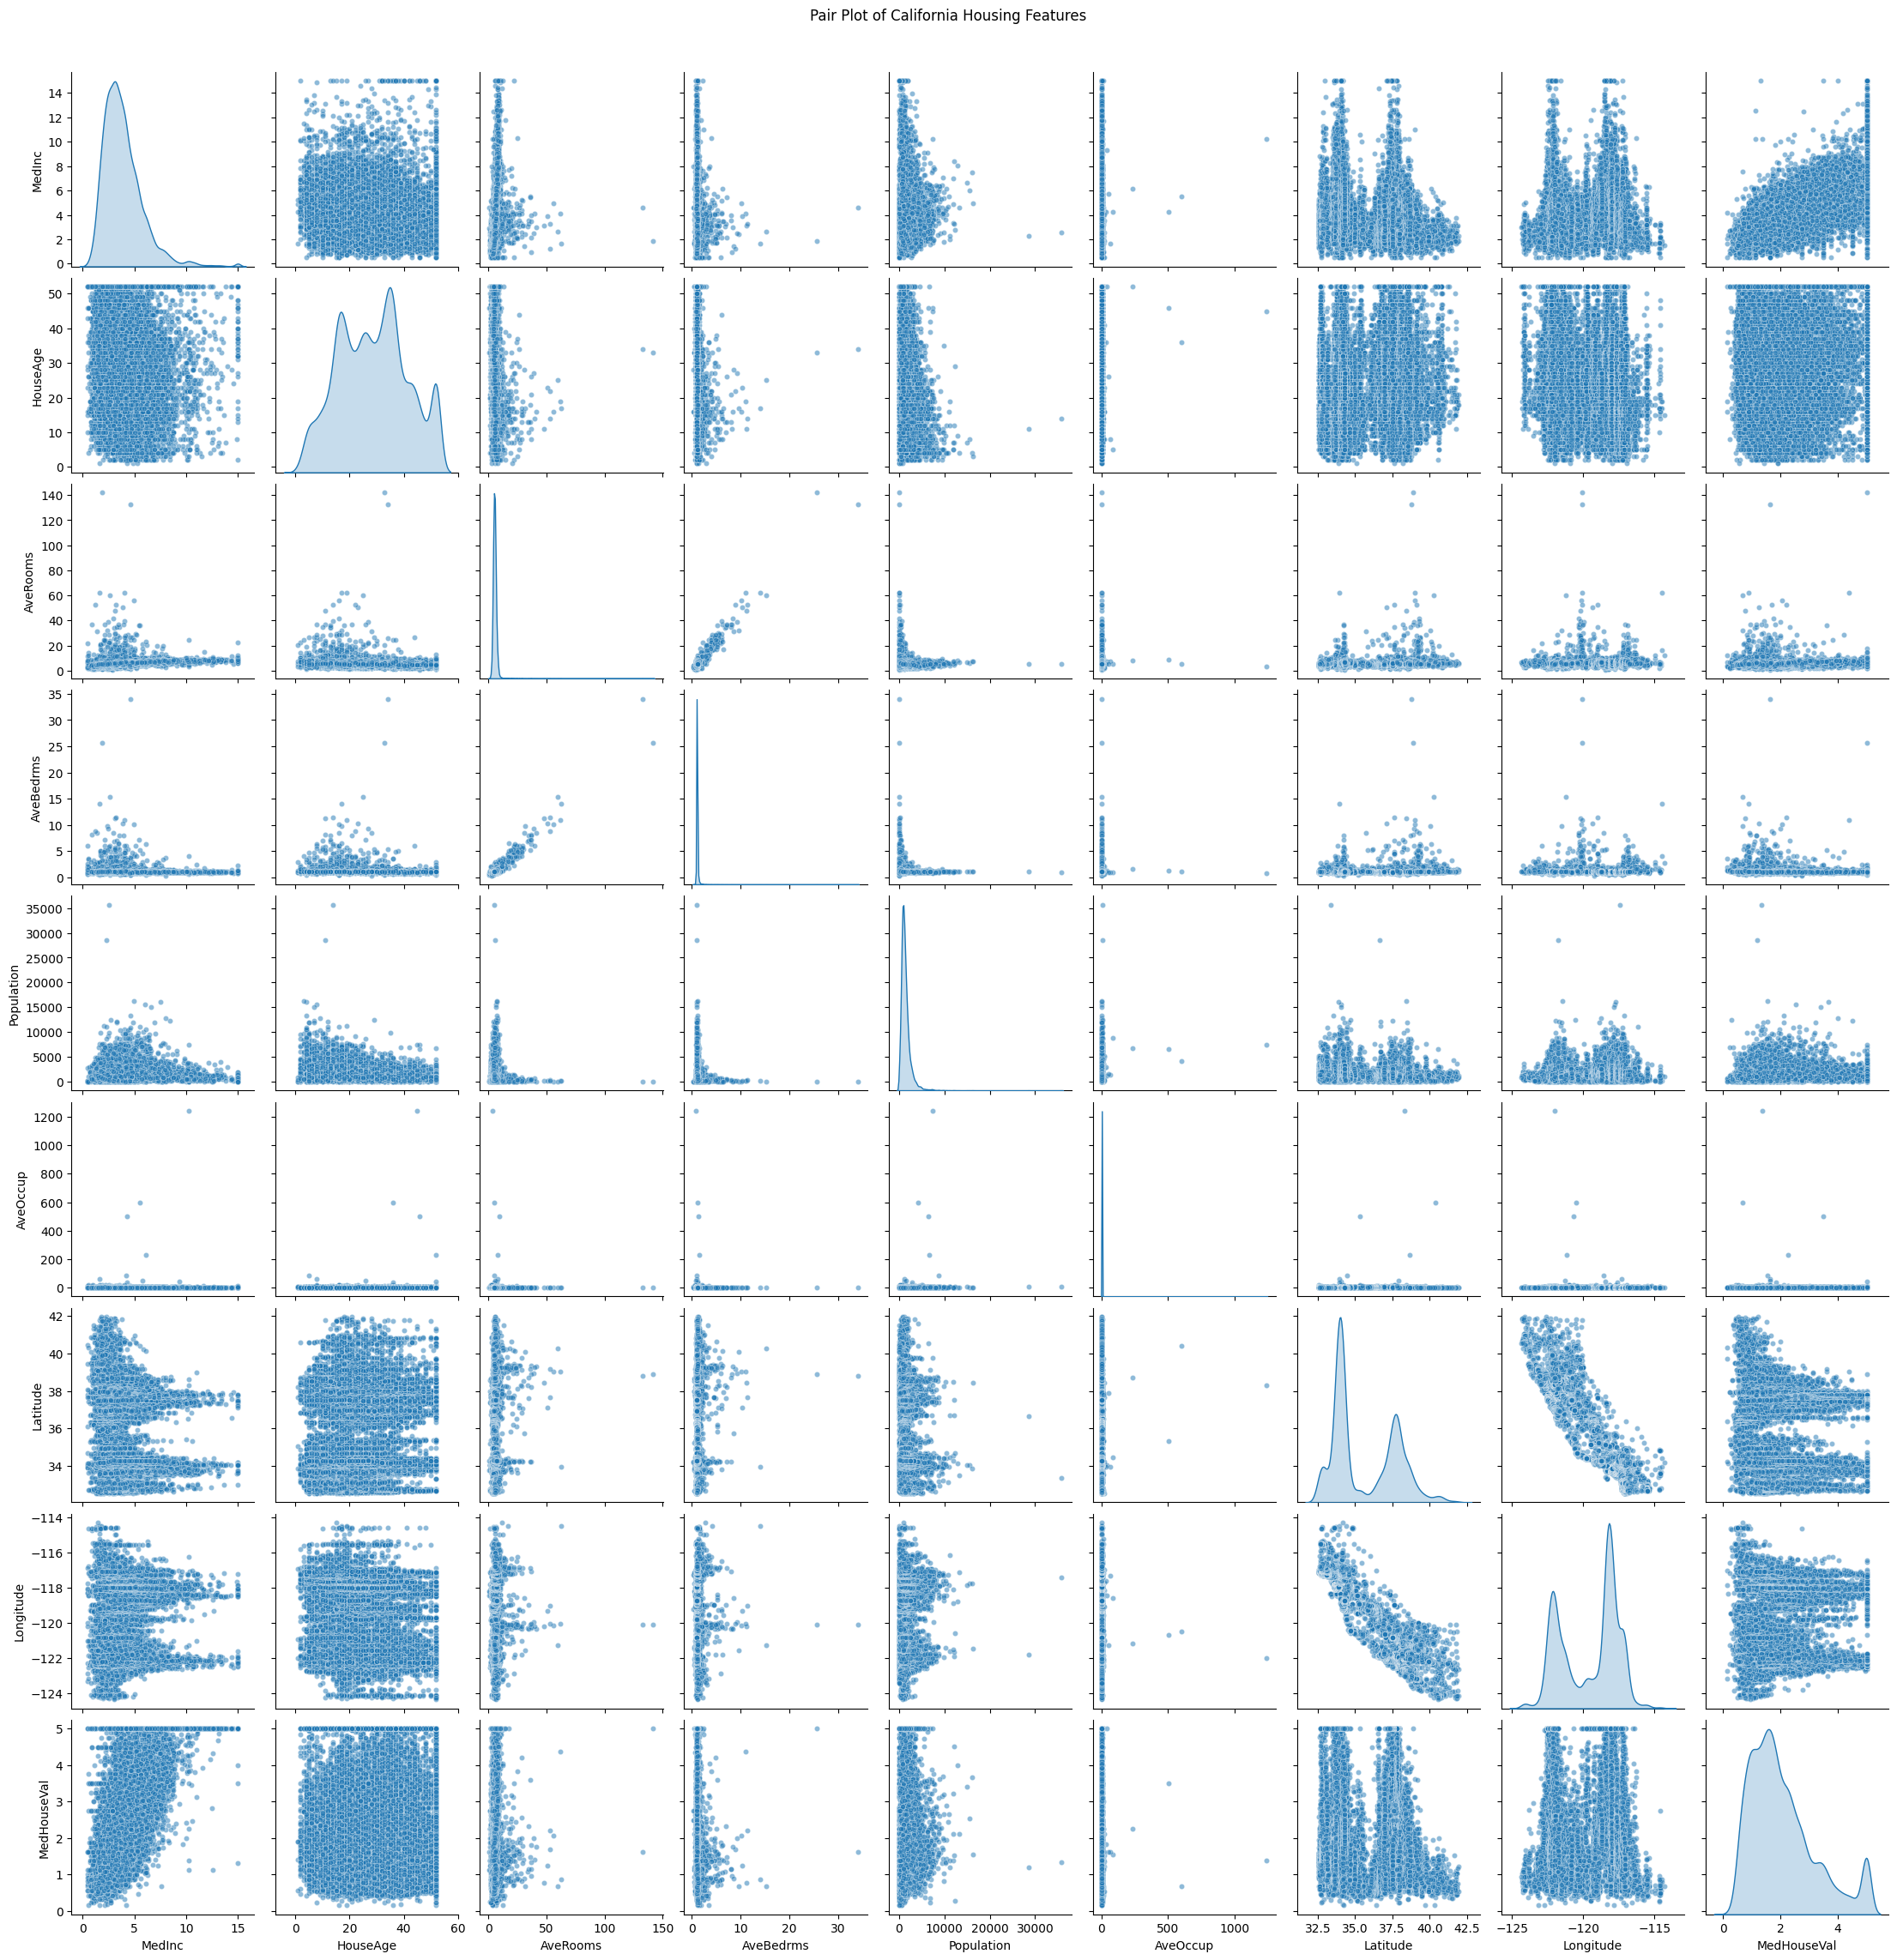

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
# Load dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# 1. Compute correlation matrix
corr_matrix = df.corr()

# 2. Visualize correlation matrix with heatmap
plt.figure(figsize=(10, 8)) # Optional

sns.heatmap(corr_matrix, annot=True,  fmt=".2f", cmap='coolwarm', square=True, cbar=True, linewidths=0.5)
#plt.title("Correlation Matrix Heatmap - California Housing") # Optional

# 3. Pair plot to visualize pairwise relationships
# (for clarity, you may select a subset or all features)
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.suptitle("Pair Plot of California Housing Features", y=1.02) # Optional

3. Develop a program to implement Principal Component Analysis (PCA) for
reducing the dimensionality of the Iris dataset from 4 features to 2.


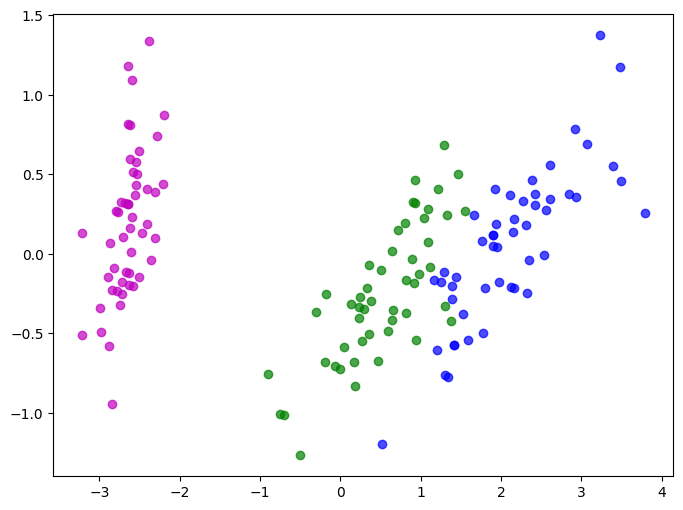

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load Iris dataset
iris = load_iris()
X = iris.data      # 4 features
y = iris.target    # class labels
target_names = iris.target_names

# Apply PCA to reduce dimensions from 4 to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

# Plot the 2D PCA result
plt.figure(figsize=(8,6))
colors = ['m', 'g', 'b']
for target, color, label in zip([0, 1, 2], colors, target_names):
    subset = df_pca[df_pca['target'] == target]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, color=color, alpha=0.7)

4. For a given set of training data examples stored in a .CSV file, implement and
demonstrate the Find-S algorithm to output a description of the set of all
hypotheses consistent with the training examples.


In [24]:
import numpy as np
import pandas as pd
data = pd.read_csv('/content/finds_dataset.csv')
def train(concepts, target):
  for i, val in enumerate(target):
    if val == "Yes":
      specific_h = concepts[i]
      break
  for i,h in enumerate(concepts):
    if target[i] == "Yes":
      for x in range(len(specific_h)):
        if h[x] == specific_h[x]:
            pass
        else:
            specific_h[x] = "?"
  return specific_h
concepts = np.array(data.iloc[:,0:-1])
target = np.array(data.iloc[:,-1])
print(train(concepts,target))

['?' 'Warm' '?' '?' '?' '?']


5. Develop a program to implement k-Nearest Neighbour algorithm to classify
the randomly generated 100 values of x in the range of [0,1]. Perform the
following based on dataset generated. 1. Label the first 50 points {x1,……,x50}
as follows: if (xi ≤ 0.5), then xi ε Class1, else xi ε Class1 2. Classify the remaining
points, x51,……,x100 using KNN. Perform this for k=1,2,3,4,5,20,30



KNN Classification Results:
  k   x_test[i]  Predicted Class
-----------------------------------

Results for k = 1
  1      0.5702                2
  1      0.4386                1
  1      0.9884                2
  1      0.1020                1
  1      0.2089                1

Results for k = 2
  2      0.5702                2
  2      0.4386                1
  2      0.9884                2
  2      0.1020                1
  2      0.2089                1

Results for k = 3
  3      0.5702                2
  3      0.4386                1
  3      0.9884                2
  3      0.1020                1
  3      0.2089                1

Results for k = 4
  4      0.5702                2
  4      0.4386                1
  4      0.9884                2
  4      0.1020                1
  4      0.2089                1

Results for k = 5
  5      0.5702                2
  5      0.4386                1
  5      0.9884                2
  5      0.1020                1
  5      0.2089 

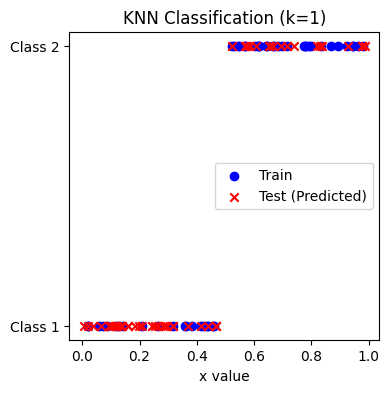

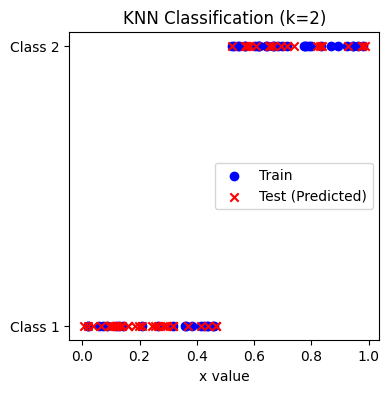

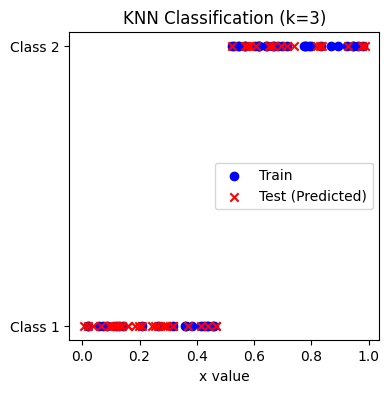

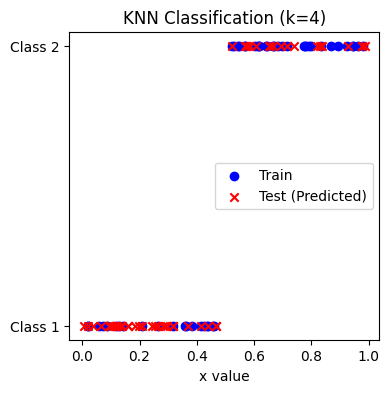

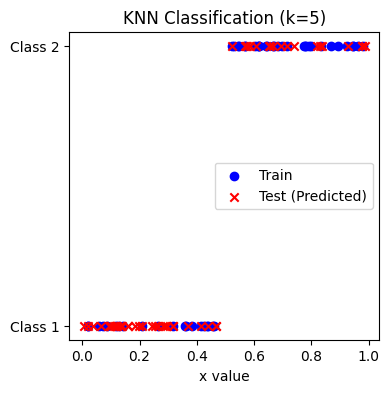

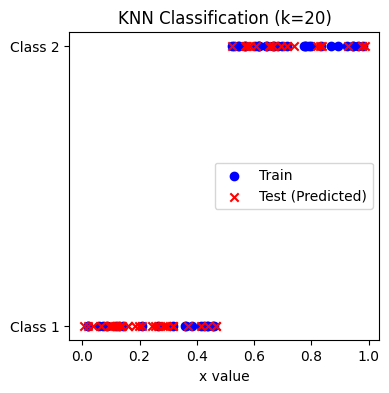

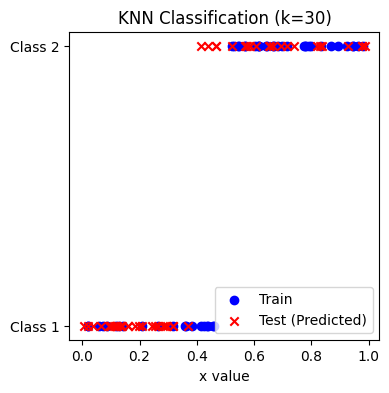

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Step 1: Generate 100 random values in [0,1]
np.random.seed(0)  # For reproducibility
x_all = np.random.rand(100).reshape(-1, 1)  # Shape (100, 1)

# Step 2: Label first 50 points
y_train = np.where(x_all[:50] <= 0.5, 1, 2)  # Class 1 if x <= 0.5 else Class 2

# Prepare training and test sets
x_train = x_all[:50]
x_test = x_all[50:]

# Step 3: Classify remaining 50 points using KNN for various k
k_values = [1, 2, 3, 4, 5, 20, 30]

print("KNN Classification Results:") #optional
print(f"{'k':>3}  {'x_test[i]':>10}  {'Predicted Class':>15}")
print("-" * 35)   #optional

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    print(f"\nResults for k = {k}")
    for i in range(5):  # Print just first 5 predictions for clarity
        print(f"{k:>3}  {x_test[i][0]:>10.4f}  {y_pred[i]:>15}")

    # Optional: Plot 39-40
    plt.figure(figsize=(4, 4))
    plt.scatter(x_train, y_train, color='blue', label='Train', marker='o')
    plt.scatter(x_test, y_pred, color='red', label='Test (Predicted)', marker='x')
    plt.title(f'KNN Classification (k={k})')
    plt.xlabel('x value')
    plt.yticks([1, 2], ['Class 1', 'Class 2'])
    plt.legend()

6 Implement the non-parametric Locally Weighted Regression algorithm in order
to fit data points. Select appropriate data set for your experiment and draw
graphs



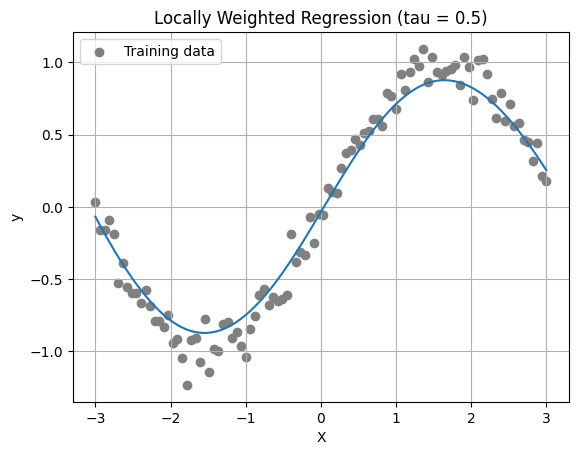

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(scale=0.1, size=X.shape)

# Reshape for matrix operations
X = X.reshape(-1, 1)
m = len(X)

# Add intercept term to X
X_aug = np.hstack([np.ones((m, 1)), X])

# Gaussian kernel function
def kernel(x0, x, tau):
    return np.exp(-np.sum((x - x0)**2, axis=1) / (2 * tau**2))

# Locally Weighted Linear Regression function
def lwlr_predict(X_train, y_train, x0, tau):
    m = X_train.shape[0]
    weights = kernel(x0, X_train, tau)
    W = np.diag(weights)

    # Normal equation: θ = (Xᵗ W X)⁻¹ Xᵗ W y
    X_aug = np.hstack([np.ones((m, 1)), X_train])
    theta = np.linalg.pinv(X_aug.T @ W @ X_aug) @ X_aug.T @ W @ y_train
    x0_aug = np.hstack([1, x0])    # Bias
    return x0_aug @ theta

# Predict for multiple x values
tau = 0.5  # bandwidth parameter
X_test = np.linspace(-3, 3, 300).reshape(-1, 1)
y_pred = np.array([lwlr_predict(X, y, x0, tau) for x0 in X_test])

# Plotting
plt.scatter(X, y, color='gray', label='Training data')

plt.plot(X_test, y_pred )
#Remaining lines are optional
plt.title("Locally Weighted Regression (tau = 0.5)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

7. Develop a program to demonstrate the working of Linear Regression and
Polynomial Regression. Use Boston Housing Dataset for Linear Regression and
Auto MPG Dataset (for vehicle fuel efficiency prediction) for Polynomial
Regression.



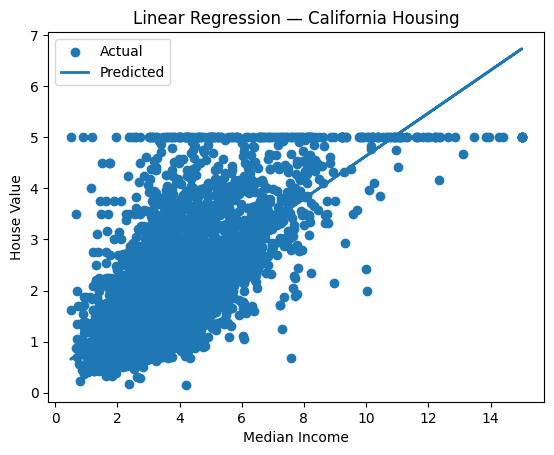

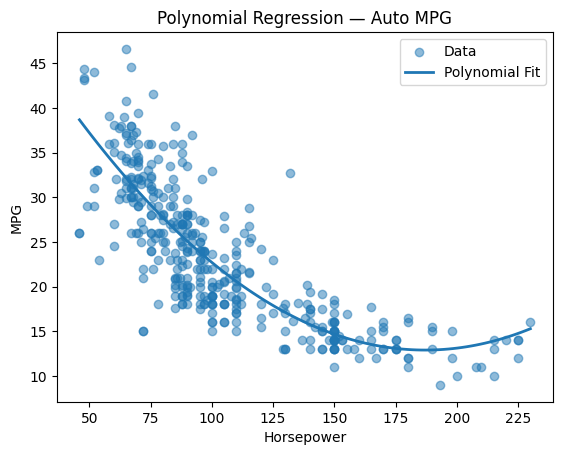

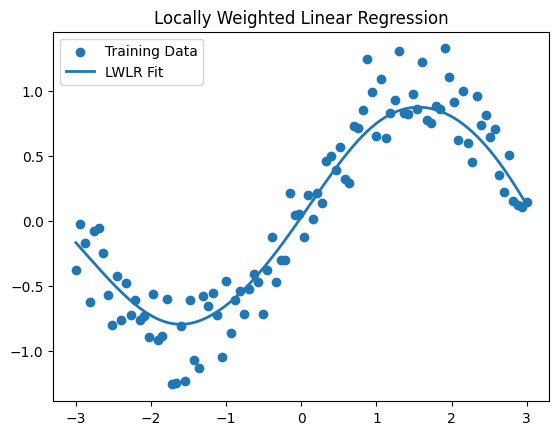

In [27]:
# ===================== IMPORTS =====================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

warnings.filterwarnings('ignore')


# ===================== PART 1 — LINEAR REGRESSION =====================

def linear_regression_california():

    # Load California Housing dataset (replacement for Boston)
    housing = fetch_california_housing()
    X = pd.DataFrame(housing.data, columns=housing.feature_names)
    y = housing.target

    # Use one feature for simple regression
    X_feat = X[['MedInc']]

    X_train, X_test, y_train, y_test = train_test_split(
        X_feat, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")
    plt.plot(X_test, y_pred, linewidth=2, label="Predicted")
    plt.xlabel("Median Income")
    plt.ylabel("House Value")
    plt.title("Linear Regression — California Housing")
    plt.legend()
    plt.show()


# ===================== PART 2 — POLYNOMIAL REGRESSION =====================

def polynomial_regression_auto_mpg():

    mpg = sns.load_dataset('mpg').dropna()

    X = mpg[['horsepower']]
    y = mpg['mpg']

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_poly, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    plt.figure()
    plt.scatter(X, y, alpha=0.5, label="Data")
    plt.plot(X_plot, y_plot, linewidth=2, label="Polynomial Fit")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.title("Polynomial Regression — Auto MPG")
    plt.legend()
    plt.show()


# ===================== PART 3 — LOCALLY WEIGHTED REGRESSION =====================

def locally_weighted_regression():

    # synthetic dataset
    X = np.linspace(-3, 3, 100)
    y = np.sin(X) + np.random.normal(0, 0.2, 100)

    X = X.reshape(-1, 1)

    def kernel(x0, X, tau):
        return np.exp(-np.sum((X - x0)**2, axis=1) / (2 * tau**2))

    def lwlr_predict(X_train, y_train, x0, tau):
        m = X_train.shape[0]
        W = np.diag(kernel(x0, X_train, tau))
        X_aug = np.hstack([np.ones((m, 1)), X_train])
        theta = np.linalg.pinv(X_aug.T @ W @ X_aug) @ X_aug.T @ W @ y_train
        x0_aug = np.hstack([1, x0])
        return x0_aug @ theta

    tau = 0.5
    X_test = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_pred = np.array([lwlr_predict(X, y, x0, tau) for x0 in X_test])

    plt.figure()
    plt.scatter(X, y, label="Training Data")
    plt.plot(X_test, y_pred, linewidth=2, label="LWLR Fit")
    plt.title("Locally Weighted Linear Regression")
    plt.legend()
    plt.show()


# ===================== RUN ALL =====================

linear_regression_california()
polynomial_regression_auto_mpg()
locally_weighted_regression()


8. Develop a program to demonstrate the working of the decision tree algorithm.
Use Breast Cancer Data set for building the decision tree and apply this
knowledge to classify a new sample.



In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Load Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Create Decision Tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test data: {accuracy:.2f}")

# Visualize the decision tree
plt.figure(figsize=(200, 150))
plot_tree(clf, feature_names=data.feature_names,
          class_names=data.target_names, filled=True, rounded=True)
plt.title("Decision Tree - Breast Cancer Classification")
plt.show()

# ---- Classify a New Sample ---
# Example sample: Replace with any 30-feature vector
new_sample = X.iloc[0].values.reshape(1, -1)  # Using first sample as example
prediction = clf.predict(new_sample)
print("Prediction for new sample:", data.target_names[prediction[0]])

Accuracy on test data: 0.93


Prediction for new sample: malignant


9 Develop a program to implement the Naive Bayesian classifier considering
Olivetti Face Data set for training. Compute the accuracy of the classifier,
considering a few test data sets.


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Naive Bayes Accuracy: 0.84
Confusion Matrix:
 [[3 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 4 0]
 [0 0 0 ... 0 0 4]]


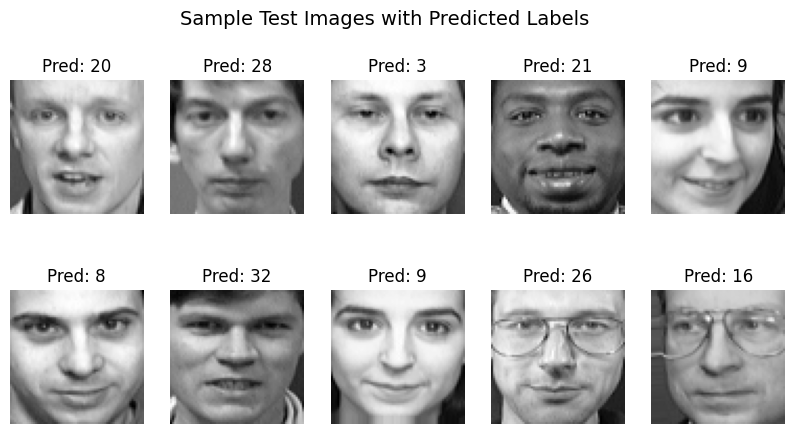

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Olivetti Faces dataset
data = fetch_olivetti_faces()
X = data.data  # Flattened image pixels (64x64 = 4096 features)
y = data.target  # Labels: 40 different individuals (0–39)

# Split into training and testing (e.g., 75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train Naive Bayes classifier
model = GaussianNB()
model.fit(X_train, y_train)
# Predict on test data
y_pred = model.predict(X_test)

# Compute and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Bayes Accuracy: {accuracy:.2f}")

# Detailed evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualize a few test faces-- Optional
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Sample Test Images with Predicted Labels", fontsize=14)
for i, ax in enumerate(axes.flat[:10]):
    ax.imshow(X_test[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}")
    ax.axis('off')

10 Develop a program to implement k-means clustering using Wisconsin Breast
Cancer data set and visualize the clustering result.



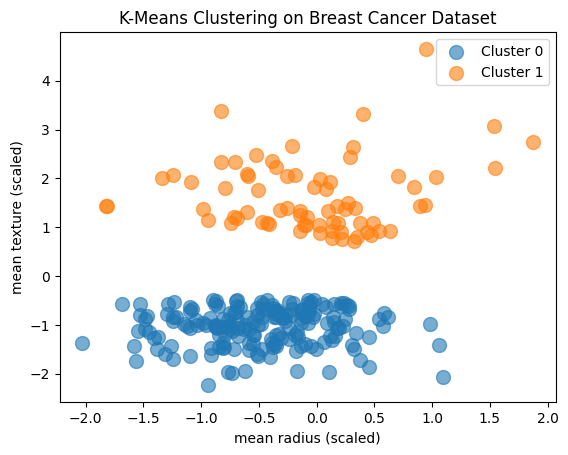

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Choose two features for clustering and plotting
feature_x = 'mean radius'
feature_y = 'mean texture'
df_selected = df[[feature_x, feature_y]]

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Plot using matplotlib
#plt.figure(figsize=(10, 6))

# Plot points with different colors for clusters
for cluster in range(2):
    plt.scatter( scaled_data[kmeans_labels == cluster, 0],
        scaled_data[kmeans_labels == cluster, 1],
        label=f'Cluster {cluster}',
        s=100,
        alpha=0.6
    )

# Plot formatting
plt.title('K-Means Clustering on Breast Cancer Dataset')
plt.xlabel(feature_x + ' (scaled)')
plt.ylabel(feature_y + ' (scaled)')
plt.legend()